In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,431 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126109 files and dire

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

#코로나데이터
df_covid = pd.read_csv('/content/drive/MyDrive/연습장/코로나데이터.csv',
                       encoding="utf-8",
                       skiprows=2,
                       header=None,
                       names=['일자', '명', '국내발생', '해외유입', '사망'],
                      usecols=[0, 1, 2, 3, 4]  # 앞 5개 열만 사용
                      )

#강수량데이터
df_rain = pd.read_csv('/content/drive/MyDrive/연습장/강수량데이터.csv',
                       encoding="cp949",
                       skiprows=12,
                       header=0,
                      )

#기온데이터
df_temp = pd.read_csv('/content/drive/MyDrive/연습장/기온데이터.csv',
                       encoding="cp949",
                       skiprows=11,
                       header=0,
                      )

#바람데이터
df_wind = pd.read_csv('/content/drive/MyDrive/연습장/바람데이터.csv',
                       encoding="cp949",
                       skiprows=15,
                       header=0,
                      )

#일조데이터
df_sun = pd.read_csv('/content/drive/MyDrive/연습장/일조데이터.csv',
                       encoding="cp949",
                       skiprows=15,
                       header=0,

                     )

#2020-01-20 ~ 2020-12-31만 추출
df_covid = df_covid[:347]
df_rain = df_rain[19:]
df_temp = df_temp[19:]
df_wind = df_wind[19:]
df_sun = df_sun[19:]


#기온데이터 에러 처리
df_temp = df_temp[['지점명', '일시']]
df_temp = df_temp.rename(columns = {'일시':'평균기온(℃)'})
df_temp = df_temp.rename(columns = {'지점명':'일시'})


#날짜 컬럼 정리
df_covid =df_covid.rename(columns = {'일자':'일시'})
df_covid['일시'] = pd.to_datetime(df_covid['일시'])
df_rain['일시'] = pd.to_datetime(df_rain['일시'])
df_temp['일시'] = pd.to_datetime(df_temp['일시'])
df_wind['일시'] = pd.to_datetime(df_wind['일시'])
df_sun['일시'] = pd.to_datetime(df_sun['일시'])


# 필요한 열만 추출 및 컬럼명 정리
df_covid = df_covid[['일시', '명']]
df_covid = df_covid.rename(columns={'명': '감염수'})

df_rain = df_rain[['일시', '강수량(mm)']].rename(columns={'강수량(mm)': '강수량'})
df_temp = df_temp[['일시', '평균기온(℃)']].rename(columns={'평균기온(℃)': '평균기온'})
df_wind = df_wind[['일시', '평균풍속(m/s)']].rename(columns={'평균풍속(m/s)': '평균풍속'})
df_sun = df_sun[['일시', '일조합(hr)']].rename(columns={'일조합(hr)': '일조합'})


# 순차적으로 병합
df = pd.merge(df_covid, df_rain, on='일시', how='left')
df = pd.merge(df, df_temp, on='일시', how='left')
df = pd.merge(df, df_wind, on='일시', how='left')
df = pd.merge(df, df_sun, on='일시', how='left')

# 최종 정리
df = df.rename(columns={'일시': '일자'})
df = df[['일자', '감염수', '강수량', '평균기온', '평균풍속', '일조합']]
df=df.fillna(0)

# 일자 정렬
df = df.sort_values(by='일자').reset_index(drop=True)

df["감염수"] = df["감염수"].str.replace(",", "").astype(float)

df


<ipython-input-192-607ab7757255>:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rain['일시'] = pd.to_datetime(df_rain['일시'])
<ipython-input-192-607ab7757255>:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_wind['일시'] = pd.to_datetime(df_wind['일시'])


,일자,감염수,강수량,평균기온,평균풍속,일조합
0,2020-01-20,1.0,0.0,0.7,2.5,8.7
1,2020-01-21,0.0,0.0,-0.4,1.4,9.2
2,2020-01-22,0.0,0.0,3.0,1.7,3.7
3,2020-01-23,0.0,0.0,4.6,2.0,8.8
4,2020-01-24,1.0,0.0,2.8,1.7,8.8
...,...,...,...,...,...,...
342,2020-12-27,970.0,0.0,5.8,1.8,5.9
343,2020-12-28,806.0,1.3,6.7,1.4,8.0
344,2020-12-29,1043.0,0.2,0.1,2.9,0.0
345,2020-12-30,1050.0,0.0,-10.9,4.1,8.3


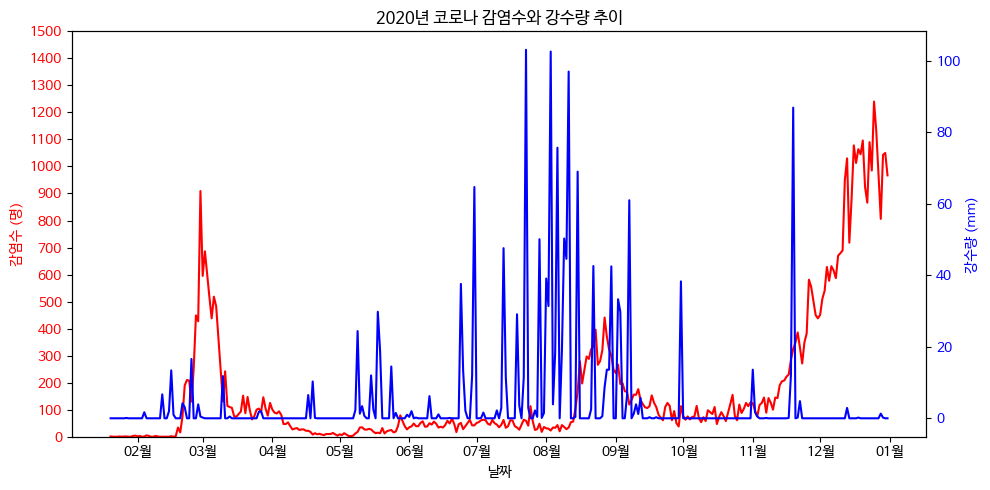

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator
import pandas as pd

df = df.sort_values(by='일자')

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df['일자'], df["감염수"], color="red", label="감염수")
ax1.set_xlabel("날짜")
ax1.set_ylabel("감염수 (명)", color="red")
ax1.tick_params(axis="y", labelcolor="red")

ax1.set_ylim(0, 1500)  # 최대 200까지 범위로 제한
ax1.yaxis.set_major_locator(MultipleLocator(100))

ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m월'))

ax2 = ax1.twinx()
ax2.plot(df['일자'], df["강수량"], color="blue", label="강수량")
ax2.set_ylabel("강수량 (mm)", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

plt.title("2020년 코로나 감염수와 강수량 추이")
fig.tight_layout()
plt.show()


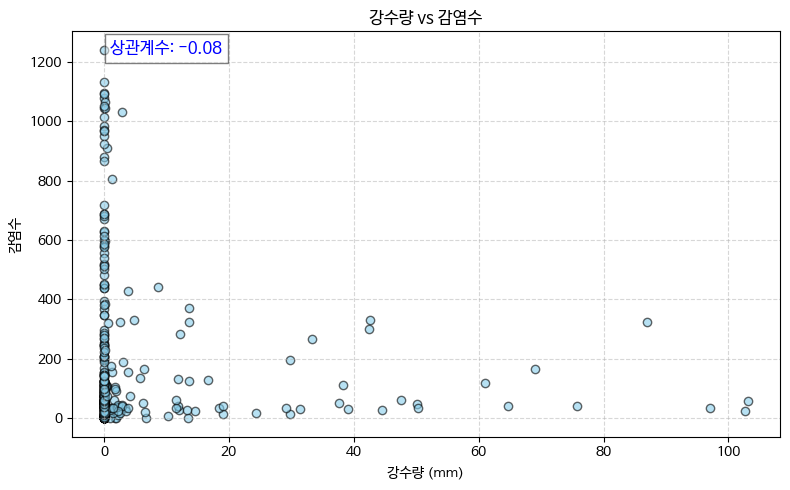

In [ ]:
import matplotlib.pyplot as plt

# 1행 1열 subplot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# 산점도: 강수량 vs 감염수
ax.scatter(df["강수량"], df["감염수"], color="skyblue", alpha=0.6, edgecolors="black")

# 상관계수 계산
corr = df["강수량"].corr(df["감염수"])

# 축 라벨 및 제목
ax.set_xlabel("강수량 (mm)")
ax.set_ylabel("감염수")
ax.set_title("강수량 vs 감염수")
ax.grid(True, linestyle="--", alpha=0.5)

# 상관계수 텍스트 박스
ax.text(
    x=min(df["강수량"]) + 1,
    y=max(df["감염수"]) - 10,
    s=f"상관계수: {corr:.2f}",
    fontsize=12,
    color="blue",
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="black")
)

plt.tight_layout()
plt.show()


<ipython-input-180-1a46ed3edfb0>:28: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


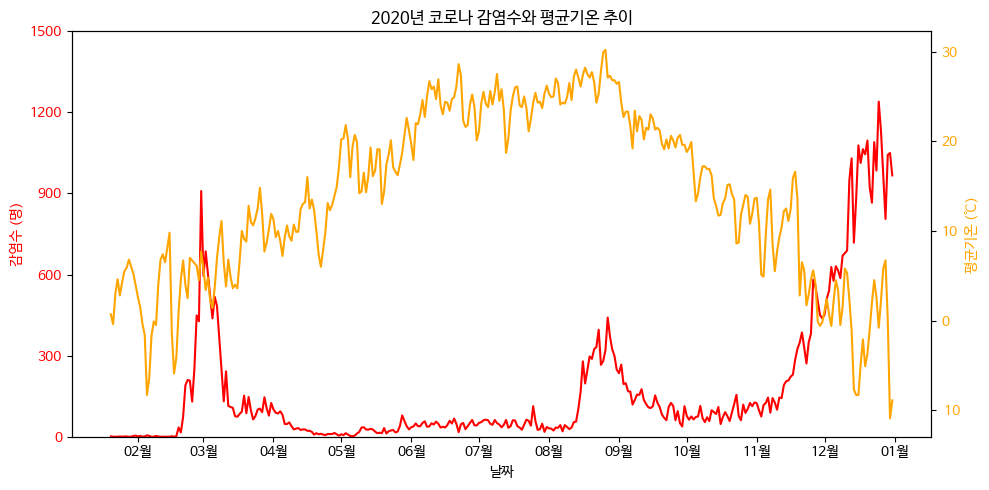

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator

df = df.sort_values(by='일자')

fig, ax1 = plt.subplots(figsize=(10, 5))

# 감염수 라인 (왼쪽 y축)
ax1.plot(df['일자'], df["감염수"], color="red", label="감염수")
ax1.set_xlabel("날짜")
ax1.set_ylabel("감염수 (명)", color="red")
ax1.tick_params(axis="y", labelcolor="red")
ax1.set_ylim(0, 1500)
ax1.yaxis.set_major_locator(MultipleLocator(300))

# x축 날짜 포맷
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m월'))

# 평균기온 라인 (오른쪽 y축)
ax2 = ax1.twinx()
ax2.plot(df['일자'], df["평균기온"], color="orange", label="평균기온")
ax2.set_ylabel("평균기온 (℃)", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

plt.title("2020년 코로나 감염수와 평균기온 추이")
fig.tight_layout()
plt.show()


<ipython-input-181-38e20445a59f>:27: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()


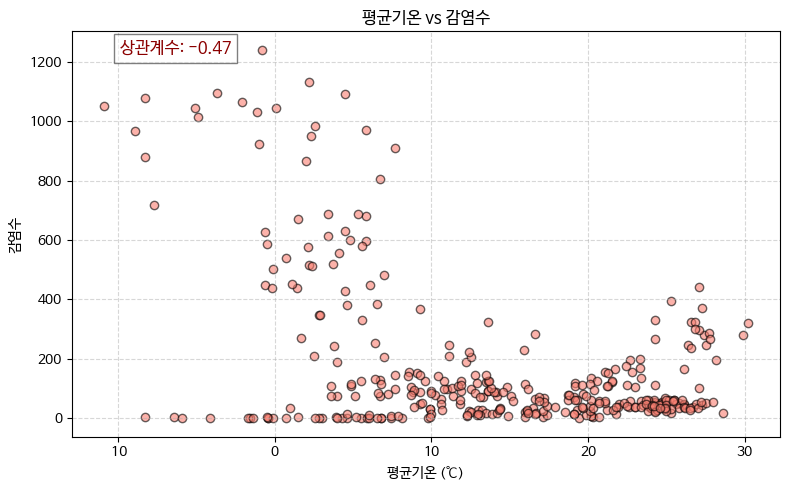

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# 산점도: 평균기온 vs 감염수
ax.scatter(df["평균기온"], df["감염수"], color="salmon", alpha=0.6, edgecolors="black")

# 상관계수 계산
corr = df["평균기온"].corr(df["감염수"])

# 축 라벨 및 제목
ax.set_xlabel("평균기온 (℃)")
ax.set_ylabel("감염수")
ax.set_title("평균기온 vs 감염수")
ax.grid(True, linestyle="--", alpha=0.5)

# 상관계수 텍스트 박스
ax.text(
    x=min(df["평균기온"]) + 1,
    y=max(df["감염수"]) - 10,
    s=f"상관계수: {corr:.2f}",
    fontsize=12,
    color="darkred",
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="black")
)

plt.tight_layout()
plt.show()


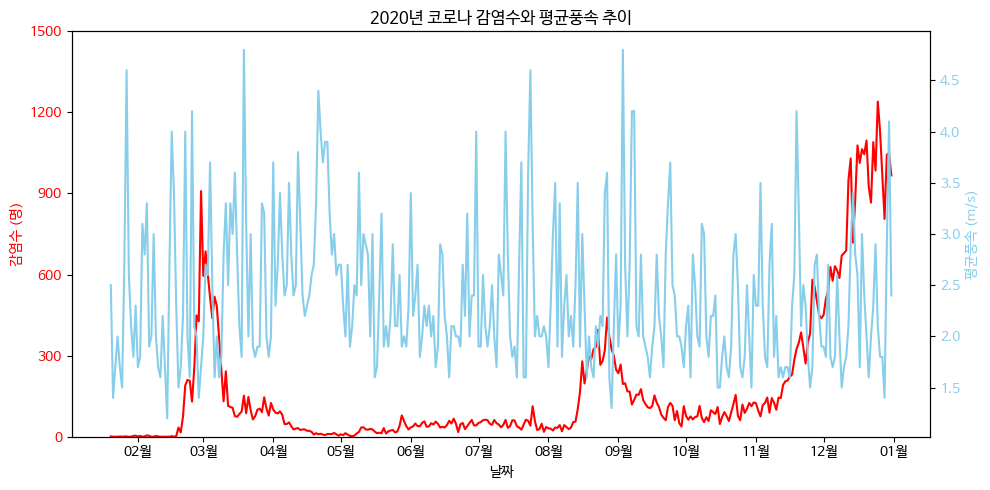

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator

df = df.sort_values(by='일자')

fig, ax1 = plt.subplots(figsize=(10, 5))

# 감염수 라인 (왼쪽 y축)
ax1.plot(df['일자'], df["감염수"], color="red", label="감염수")
ax1.set_xlabel("날짜")
ax1.set_ylabel("감염수 (명)", color="red")
ax1.tick_params(axis="y", labelcolor="red")
ax1.set_ylim(0, 1500)
ax1.yaxis.set_major_locator(MultipleLocator(300))

# x축 날짜 포맷
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m월'))

# 평균풍속 라인 (오른쪽 y축)
ax2 = ax1.twinx()
ax2.plot(df['일자'], df["평균풍속"], color="skyblue", label="평균풍속")
ax2.set_ylabel("평균풍속 (m/s)", color="skyblue")
ax2.tick_params(axis="y", labelcolor="skyblue")

plt.title("2020년 코로나 감염수와 평균풍속 추이")
fig.tight_layout()
plt.show()


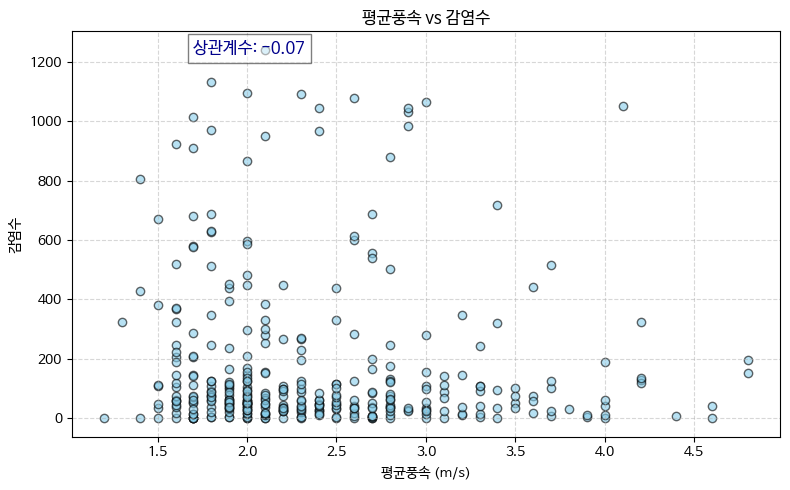

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# 산점도: 평균풍속 vs 감염수
ax.scatter(df["평균풍속"], df["감염수"], color="skyblue", alpha=0.6, edgecolors="black")

# 상관계수 계산
corr = df["평균풍속"].corr(df["감염수"])

# 축 라벨 및 제목
ax.set_xlabel("평균풍속 (m/s)")
ax.set_ylabel("감염수")
ax.set_title("평균풍속 vs 감염수")
ax.grid(True, linestyle="--", alpha=0.5)

# 상관계수 텍스트 박스
ax.text(
    x=min(df["평균풍속"]) + 0.5,
    y=max(df["감염수"]) - 10,
    s=f"상관계수: {corr:.2f}",
    fontsize=12,
    color="darkblue",
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="black")
)

plt.tight_layout()
plt.show()


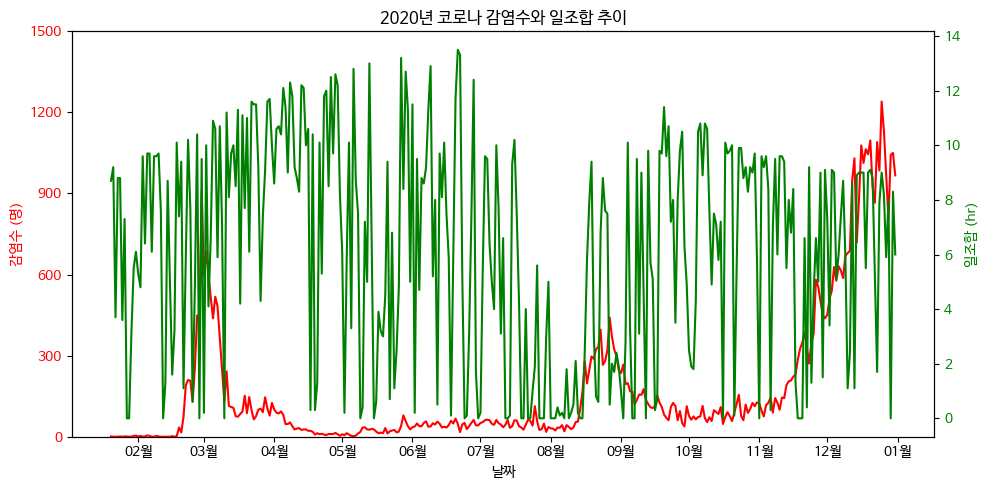

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator

df = df.sort_values(by='일자')

fig, ax1 = plt.subplots(figsize=(10, 5))

# 감염수 라인 (왼쪽 y축)
ax1.plot(df['일자'], df["감염수"], color="red", label="감염수")
ax1.set_xlabel("날짜")
ax1.set_ylabel("감염수 (명)", color="red")
ax1.tick_params(axis="y", labelcolor="red")
ax1.set_ylim(0, 1500)
ax1.yaxis.set_major_locator(MultipleLocator(300))

# x축 날짜 포맷 (1월~12월)
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m월'))

# 일조합 라인 (오른쪽 y축)
ax2 = ax1.twinx()
ax2.plot(df['일자'], df["일조합"], color="green", label="일조합")
ax2.set_ylabel("일조합 (hr)", color="green")
ax2.tick_params(axis="y", labelcolor="green")

plt.title("2020년 코로나 감염수와 일조합 추이")
fig.tight_layout()
plt.show()


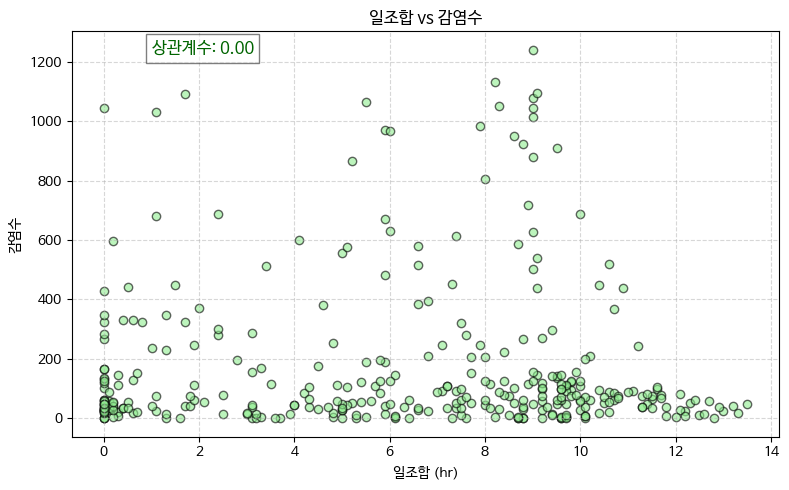

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# 산점도: 일조합 vs 감염수
ax.scatter(df["일조합"], df["감염수"], color="lightgreen", alpha=0.6, edgecolors="black")

# 상관계수 계산
corr = df["일조합"].corr(df["감염수"])

# 축 라벨 및 제목
ax.set_xlabel("일조합 (hr)")
ax.set_ylabel("감염수")
ax.set_title("일조합 vs 감염수")
ax.grid(True, linestyle="--", alpha=0.5)

# 상관계수 텍스트 박스
ax.text(
    x=min(df["일조합"]) + 1,
    y=max(df["감염수"]) - 10,
    s=f"상관계수: {corr:.2f}",
    fontsize=12,
    color="darkgreen",
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="black")
)

plt.tight_layout()
plt.show()
